<a href="https://colab.research.google.com/github/eljaysmithdata/Data-Science-Bootcamp-2026/blob/main/Project_4_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Predicting Spotify Streams with Tree-Based Regression

AI Disclosure: ChatGPT was used to support concept clarification, wording refinement and visualization formatting. Final code execution and submission decisions were completed independently.



### Introduction





#### Problem Statement

**Can Spotify audio features help predict how many streams a song receives?**

This project uses **Spotify stream count** as the target variable.

Although the original project prompt refers to predicting popularity, I chose **Streams** because it is a more direct and transparent measure of listening behavior. Spotify popularity is partly algorithmic and not fully transparent. Stream count is still imperfect, but it is easier to explain, easier to evaluate, and better aligned with the question:

> Can the sound profile of a song help predict listener reach?

This is a **supervised regression** problem because:

- The target variable is numeric.
- The model learns from past examples.
- The goal is to predict a continuous stream count.

#### Guiding Analogy: The Mixing Board

I think of each audio feature as a channel on a mixing board.

Each feature gives the model one possible signal:

- Danceability
- Energy
- Acousticness
- Valence
- Liveness
- Tempo
- Duration

The model is listening for which channels help explain stream count.

The goal is not to prove that audio features fully explain popularity.  
The goal is to test whether the sound profile carries any useful predictive signal.

## Imports

In [1]:
# ============================================================
# Import Libraries
# ============================================================

# Core data tools
import pandas as pd
import numpy as np

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling tools
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Set options and themes
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## Read in Data

First, I load the Spotify dataset.

This gives me the raw data before cleaning, feature selection, or modeling.

In [2]:
# ============================================================
# Read Data
# ============================================================

# Create url variable
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"

# Read data
spotify = pd.read_csv(url)


In [3]:
# Preview the first few rows to confirm the data loaded correctly

spotify.head()

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


## Initial Data Quality

Before choosing the final model inputs, I need to understand the dataset.

This helps me check:

- how many rows and columns are in the data
- what columns are available
- whether the data types make sense
- whether there are missing values
- whether there are duplicate rows

This is like checking whether every channel on the mixing board is plugged in before recording.



In [4]:
# ============================================================
# Initial Dataset Shape
# ============================================================

# Display shape of data
print("Dataset shape:", spotify.shape)

Dataset shape: (1556, 23)


In [5]:
# ============================================================
# Column Names and Data Types
# ============================================================

# This shows column names, data types, row counts, and missing values

spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

### Check for Duplicates

In [6]:
# ============================================================
# Duplicate Check
# ============================================================

# This shows no duplicates across the full original dataset

duplicate_count = spotify.duplicated().sum()

print("Number of fully duplicated rows:", duplicate_count)

Number of fully duplicated rows: 0


### Check for Missing Data

In [7]:
# ============================================================
# Missing Values in Full Dataset
# ============================================================

spotify.isnull().sum()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


Initial Data Quality Interpretation:

At first glance, the dataset appears very clean:

- No duplicate rows were found
- No missing values were detected
- Most columns appear populated correctly

However, the `.info()` output reveals an important hidden issue:

Several columns that should contain numerical values are currently stored as `object` data types instead of numeric types (`int64` or `float64`).

This commonly happens when:

- numbers contain commas or formatting symbols
- values were imported as text during CSV loading
- mixed formatting exists within a column

This matters because machine learning models and statistical analysis require numerical columns to be stored in a true numeric format.

This can hide data quality problems because some invalid or missing numeric values may still be stored as text.

Even though the dataset appears to have no missing values, the data types themselves still need to be cleaned before analysis and modeling can begin.

This is an example of a structural data quality issue rather than a missing-data issue.

### Convert Numeric Columns

The next step is to convert incorrectly formatted numerical columns into proper numeric data types so they can be used for statistical analysis and machine learning.

In [8]:
# ============================================================
# Convert Numeric-Looking Columns
# ============================================================

numeric_columns = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Liveness",
    "Valence",
    "Tempo",
    "Duration (ms)",
    "Streams"
]

for col in numeric_columns:
    spotify[col] = (
        spotify[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    spotify[col] = pd.to_numeric(spotify[col], errors="coerce")

# Confirm conversion worked
display(spotify[numeric_columns].dtypes)

,0
Danceability,float64
Energy,float64
Loudness,float64
Speechiness,float64
Acousticness,float64
Liveness,float64
Valence,float64
Tempo,float64
Duration (ms),float64
Streams,int64


In [9]:
# ============================================================
# Missing Values in Converted Dataset
# ============================================================

spotify.isnull().sum()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


Missing Values After Conversion:

After converting the columns into numeric format, new missing values now appear in several audio-feature columns.

This happened because some values could not be successfully interpreted as numbers during conversion. When pandas encounters invalid or improperly formatted entries during numeric conversion, those values are automatically replaced with `NaN` (missing values).

This is an important step in the data cleaning process because it exposes hidden formatting problems that were previously disguised when the columns were stored as text (`object`) types.

The affected columns now require additional cleaning decisions before modeling can begin.

### Initial Summary Statistics

In [10]:
# ============================================================
# Summary Statistics After Numeric Conversion
# ============================================================

# describe(include="all") summarizes both numerical and categorical columns
# .transpose() flips the table so each variable is easier to read row by row

spotify.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,"1,556.000",NaN,NaN,NaN,778.500,449.323,1.000,389.750,778.500,"1,167.250","1,556.000"
Highest Charting Position,"1,556.000",NaN,NaN,NaN,87.744,58.147,1.000,37.000,80.000,137.000,200.000
Number of Times Charted,"1,556.000",NaN,NaN,NaN,10.668,16.361,1.000,1.000,4.000,12.000,142.000
Week of Highest Charting,1556,83,2019-12-27--2020-01-03,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Song Name,1556,1556,Lover (Remix) [feat. Shawn Mendes],1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Streams,"1,556.000",NaN,NaN,NaN,"6,340,219.379","3,369,478.841","4,176,083.000","4,915,322.250","5,275,747.500","6,455,044.250","48,633,449.000"
Artist,1556,716,Taylor Swift,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist Followers,1556,600,42227614,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Song ID,1556,1517,,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,1556,395,[],75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Early Understanding of the Dataset:

The initial summary statistics show that the numerical variables behave very differently from each other.

Some variables, such as `Danceability`, `Energy`, `Acousticness`, `Liveness`, and `Valence`, are measured on a small 0-to-1 scale.

Other variables, such as `Streams`, `Artist Followers`, `Tempo`, and `Duration (ms)`, are measured on much larger scales.

The target variable, `Streams`, appears especially spread out, which suggests that the dataset is highly uneven: most songs have lower or moderate streaming totals, while a smaller number of songs have very high streaming totals.

This tells me that the dataset likely contains strong right skew, possible outliers, and large differences in scale between features.

This helps establish an early understanding of the dataset before deeper analysis and modeling.

---

## Target and Feature Selection

Now I define the target and first set of modeling features.

Why I Am Using Only Numeric Audio Features?

For this first version of the model, I am intentionally using only numeric audio features.

This choice keeps the project focused, simple, and easier to explain for a beginner regression model.

### **Target:**

The target is:

- `Stream`

### **Features:**

- `Danceability`
- `Energy`
- `Loudness`
- `Speechiness`
- `Acousticness`
- `Liveness`
- `Valence`
- `Tempo`

The selected features are audio characteristics that could reasonably be known before or at release:

I am excluding non-audio or identity-based columns such as song title, artist name, chart position, and rank because those columns could create data leakage or make the model rely on information that is too closely connected to popularity after the fact.

I am also excluding categorical features such as genre or chord for this version.

Genre could be useful in a more advanced model, but it can also introduce extra complexity, noise, or redundancy. Genre is often a label that already summarizes patterns in audio characteristics, audience expectations, marketing categories, and cultural context. Because of that, including genre could blur the question I am trying to answer.

For this version, I want the model to answer a narrower and cleaner question:

Can the measurable sound profile of a song help predict its stream count?

In the mixing board analogy, I am only using the channels that represent direct audio measurements. I am not adding broader labels like genre yet because I first want to hear what the raw sound features can explain on their own.

In [11]:
# ============================================================
# Define Target and Features
# ============================================================

# The target is what the model will try to predict
target = 'Streams'

# These are the audio features used as model inputs
# In the analogy, these are the selected channels on the mixing board

features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Liveness",
    "Valence",
    "Tempo",
]


# ============================================================
# Create Modeling Dataset
# ============================================================

# Keep only the selected features and target
# This avoids cleaning or modeling columns that are not part of the project question

model_data = spotify[features + [target]].copy()


# Preview selected columns before cleaning
print("Focused modeling dataset shape:", model_data.shape)
model_data.head()

Focused modeling dataset shape: (1556, 9)


,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Valence,Tempo,Streams
0,0.714,0.800,-4.808,0.050,0.127,0.359,0.589,134.002,48633449
1,0.591,0.764,-5.484,0.048,0.038,0.103,0.478,169.928,47248719
2,0.563,0.664,-5.044,0.154,0.335,0.085,0.688,166.928,40162559
3,0.808,0.897,-3.712,0.035,0.047,0.364,0.591,126.026,37799456
4,0.736,0.704,-7.409,0.061,0.020,0.050,0.894,149.995,33948454


## Data Cleaning

Now I inspect only the columns that will be used in the model.

This is where the project gets cleaner.

- Are the selected columns numerical?
- Clean previously identified rows.
- Do the ranges look reasonable?
- Does `Streams` look heavily skewed?

---

#### Drop Missing Values

In [12]:
# ============================================================
# Drop Missing Values from Selected Modeling Data
# ============================================================

model_data_clean = model_data.dropna().copy()

before_rows = model_data.shape[0]
after_rows = model_data_clean.shape[0]

rows_removed = before_rows - after_rows

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", rows_removed)

Rows before cleaning: 1556
Rows after cleaning: 1545
Rows removed: 11


In [13]:
# ============================================================
# Confirm No Missing Values Remain
# ============================================================

# Check missing values only in the selected modeling columns

model_data_clean.isnull().sum()

,0
Danceability,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0
Liveness,0
Valence,0
Tempo,0
Streams,0


#### Clean Summary Statistics:

After converting the selected columns to numeric values and removing rows with missing data, the modeling dataset is now structurally clean.

The row count decreased from 1,556 to 1,545, meaning 11 rows were removed. This is a very small portion of the dataset, so removing those rows is unlikely to meaningfully distort the overall analysis.

Now I can review summary statistics again, but only for the columns that will be used in modeling.

In [14]:
# ============================================================
# Clean Summary Statistics
# ============================================================

# This summary now focuses only on the selected modeling columns
# It is more relevant than the full raw dataset summary

model_data_clean.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Danceability,"1,545.000",0.690,0.142,0.150,0.599,0.707,0.796,0.980
Energy,"1,545.000",0.633,0.162,0.054,0.532,0.642,0.752,0.970
Loudness,"1,545.000",-6.348,2.509,-25.166,-7.491,-5.990,-4.711,1.509
Speechiness,"1,545.000",0.124,0.110,0.023,0.046,0.076,0.165,0.884
Acousticness,"1,545.000",0.249,0.250,0.000,0.049,0.161,0.388,0.994
Liveness,"1,545.000",0.181,0.144,0.020,0.097,0.124,0.217,0.962
Valence,"1,545.000",0.515,0.227,0.032,0.343,0.512,0.691,0.979
Tempo,"1,545.000",122.811,29.591,46.718,97.960,122.012,143.860,205.272
Streams,"1,545.000","6,337,136.378","3,375,402.182","4,176,083.000","4,915,080.000","5,269,163.000","6,452,492.000","48,633,449.000"


Cleaned Summary Statistics Interpretation:

This second summary check is important because the first summary was incomplete. Some columns were originally stored as `object` data types, so they could not be fully evaluated until after conversion.

Now I can more accurately inspect the scale, spread, and behavior of the variables I plan to use for modeling.


The cleaned modeling dataset contains 1,545 songs and no missing values in the selected modeling columns.

The cleaned summary statistics show that the audio feature columns are mostly measured on small, bounded scales between 0 and 1.

In contrast, `Streams` is measured on a much larger scale and has a very wide spread. The minimum stream count is much lower than the maximum stream count, which suggests that some songs received far more streams than most others.

This gives me an early warning that the target variable is unevenly distributed. Before modeling, I need to examine the target distribution visually to understand whether a few very large values may dominate the prediction task.

---

## Exploratory Data Analysis

Now that the data has been cleaned and the target has been prepared in two forms, I move into exploratory data analysis.

The goal of this section is not to model yet.

The goal is to understand the shape of the data, especially:

- how `Streams` is distributed
- how `Log_Streams` changes that distribution
- whether the audio features show visible relationships with the target
- whether any variables may be more useful predictors than others

This is the “listen before modeling” stage.

---

### Target Distributions

Next, I look at the distribution of `Streams`.

A heavily skewed target does not make `Streams` wrong.

It means streaming success is uneven: a small number of songs receive very high stream counts, while most receive fewer.

That makes prediction harder, but it also reflects the real-world structure of the problem.

Because the stream count target is heavily skewed, I also look at the log version of streams.

This does not replace the original target yet. It helps me understand the data more clearly.

The log transformation makes very large values less extreme, which can make patterns easier to see.

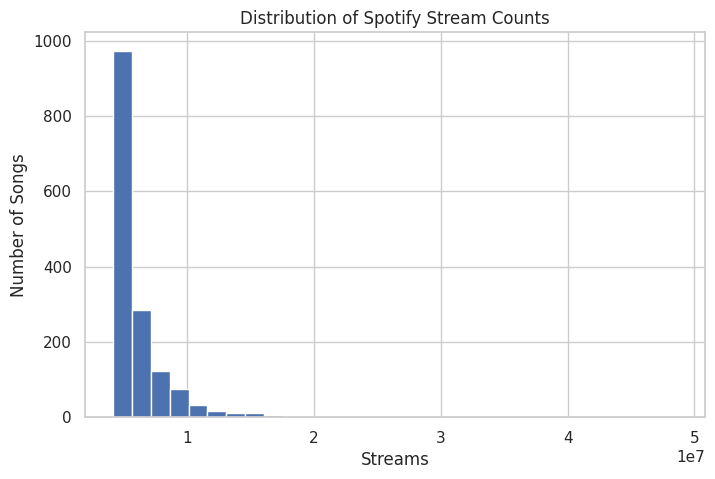

In [15]:
# ============================================================
# Distribution of Stream Counts
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    model_data['Streams'],
    bins=30
)

plt.title('Distribution of Spotify Stream Counts')
plt.xlabel('Streams')
plt.ylabel('Number of Songs')

plt.show()

#### Log-Transformed Target

Because `Streams` has a very wide range, I will create a log-transformed version called `Log_Streams`.

This does not replace the original target yet.

Instead, it gives me a second version of the target to compare against the original stream counts. The goal is to see whether reducing the effect of extremely large stream values helps the models learn patterns more effectively.

In [16]:
# ============================================================
# Create Log-Transformed Target
# ============================================================

# Log transformation helps reduce extreme skew
# in the target variable (Streams)

model_data_clean["Log_Streams"] = np.log1p(model_data_clean["Streams"])

# Preview the new column
model_data_clean[["Streams", "Log_Streams"]].head()


,Streams,Log_Streams
0,48633449,17.700
1,47248719,17.671
2,40162559,17.508
3,37799456,17.448
4,33948454,17.340


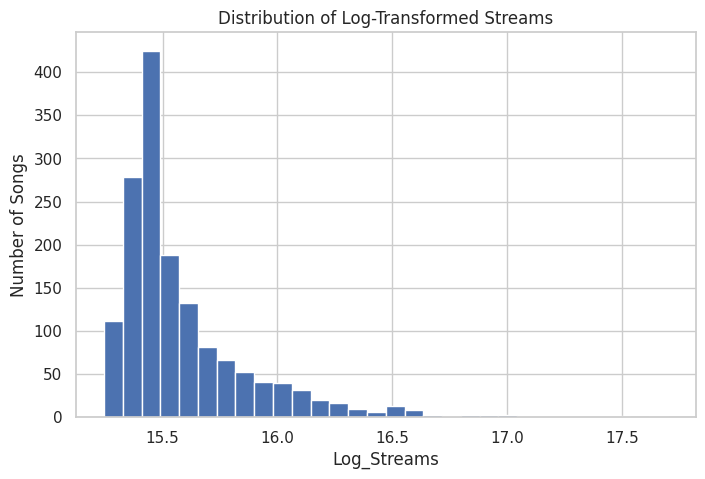

In [17]:
# ============================================================
# Distribution Log-Transformed Target
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(model_data_clean["Log_Streams"], bins=30)

plt.title("Distribution of Log-Transformed Streams")
plt.xlabel("Log_Streams")
plt.ylabel("Number of Songs")

plt.show()

**Interpretation of Raw Streams Distribution:**

The raw `Streams` distribution is heavily right-skewed.

Most songs are clustered at lower stream counts, while a small number of songs have extremely high stream counts.

This matches the real-world structure of music streaming. A few songs become major hits, while most songs receive more moderate attention.

This does not mean the target is wrong. It means the prediction problem is harder because the model has to learn from an uneven target where extreme values can have a large influence.

**Interpretation of Log-Transformed Streams Distribution:**

The log-transformed version of `Streams` compresses the extremely large stream counts.

After the transformation, the distribution is still not perfectly normal, but it is easier to read. The largest values no longer stretch the graph as aggressively.

This helps me compare two modeling paths:

1. Use `Streams` to predict the original stream count directly.
2. Use `Log_Streams` to predict a compressed version of streaming success.

This comparison is useful because tree-based models do not require normally distributed targets, but extreme skew can still affect model performance and error size.

---

### **Correlation Heatmap**

After looking at the target distributions, I now want to examine relationships between the numeric variables.

The distribution plots showed me the shape of the target, but they do not show how the features relate to each other.

The correlation heatmap gives me an early signal of which audio features may move together and which features may have stronger or weaker relationships with `Streams` and `Log_Streams`.

This step helps me move from looking at individual variables to looking at relationships across the dataset.

This helps answer:

- Do any features strongly relate to streams?
- Are some features related to each other?
- Does the data show obvious patterns before modeling?

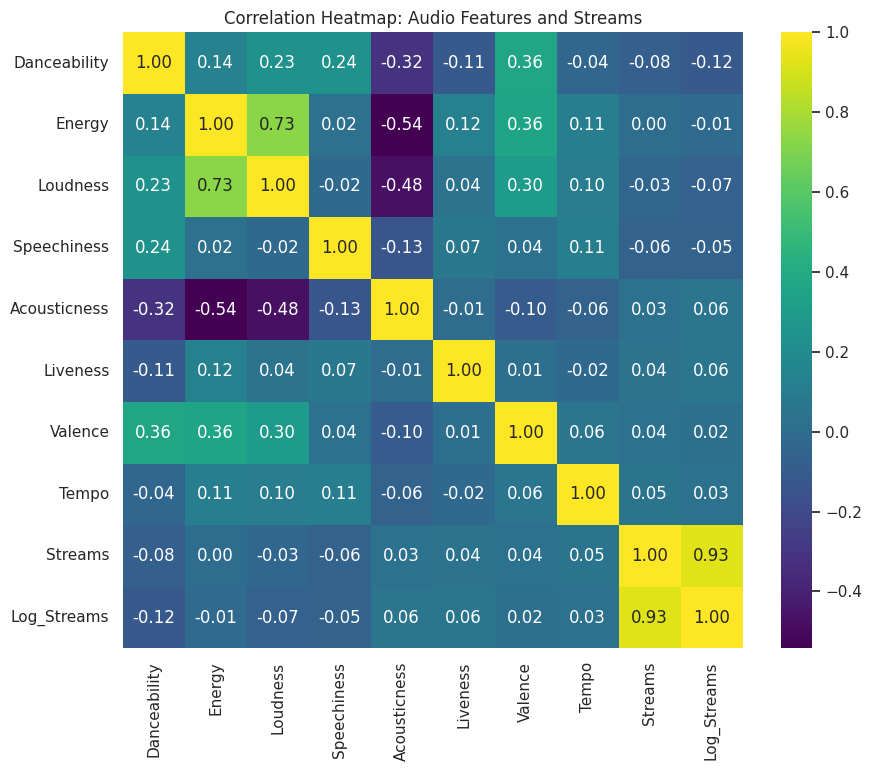

In [18]:
# ============================================================
# Correlation Heatmap
# ============================================================

corr_columns = features + ["Streams", "Log_Streams"]

plt.figure(figsize=(10, 8))
sns.heatmap(model_data_clean[corr_columns].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap: Audio Features and Streams")
plt.show()



**Correlation Heatmap Interpretation:**

The heatmap shows that no single audio feature has a strong simple correlation with streams.

This means there is no obvious one-feature answer.

That supports using tree-based models, because tree models can look for more complicated patterns and feature combinations.

---

### **Pairplot Exploration**

Next, I use a pairplot to look at relationships between selected audio features and the target.

This is a visual “first listen” to the data. Instead of testing the model yet, I am looking for early patterns, clusters, spread, or possible relationships between variables.

For this step, I include `Log_Streams` instead of raw `Streams` because the original stream counts were extremely skewed. The log version makes the target easier to compare visually with the audio features.

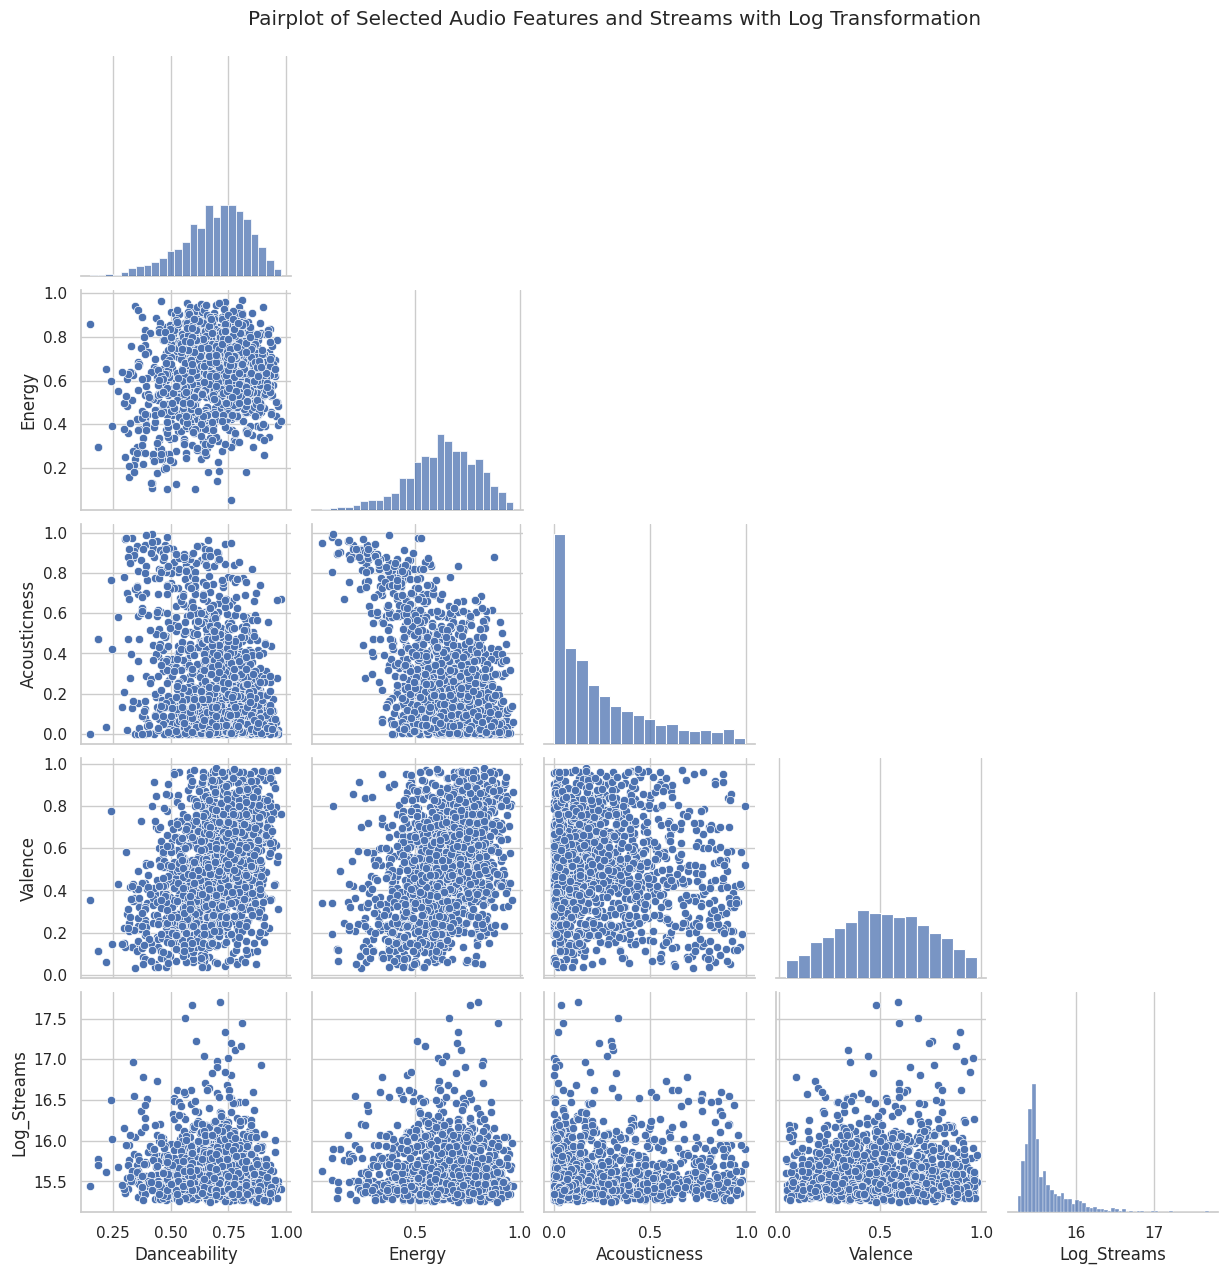

In [19]:
# ============================================================
# Select Features for Pairplot with Log Transformation
# ============================================================

# Pairplots become visually overwhelming with too many variables
# I intentionally use a smaller subset of intuitive audio features

pairplot_features = [
    'Danceability',
    'Energy',
    'Acousticness',
    'Valence',
    'Log_Streams',
]


# ============================================================
# Create Pairplot Dataset
# ============================================================

# Create a smaller dataframe for visualization

pairplot_data = model_data_clean[pairplot_features]


# ============================================================
# Create Pairplot
# ============================================================

# diag_kind='hist' creates histograms along the diagonal
# corner=True removes duplicate mirrored plots for cleaner viewing

sns.pairplot(
    pairplot_data,
    diag_kind='hist',
    corner=True
)

plt.suptitle(
    'Pairplot of Selected Audio Features and Streams with Log Transformation',
    y=1.02
)

plt.show()

**Interpreting the Pairplot:**

The pairplot helps visually explore how selected audio features interact with each other and with stream count.

Several patterns appear nonlinear rather than following a simple straight-line relationship.

This further supports using tree-based regression models, since tree-based models can capture:

- nonlinear relationships
- interaction effects
- threshold-based patterns

The pairplot also shows that no single feature perfectly explains stream count on its own.

Instead, prediction likely depends on combinations of audio characteristics interacting together.

---

### **Scatterplot Relationships**

The heatmap only shows simple linear relationships and after the pairplot gives a broad overview,
I can now zoom in on individual feature-to-target relationships.

The pairplot gives me the big picture, but individual scatterplots make it easier to inspect how each audio feature relates to `Log_Streams`.

Scatterplots help me ask a more focused question:

Do any audio features show visible patterns that might help predict streaming success?

Now I use scatterplots to look visually at how selected audio features relate to streams.

This helps me check whether there are possible nonlinear patterns or clusters.

For this visual, I use a smaller feature subset.



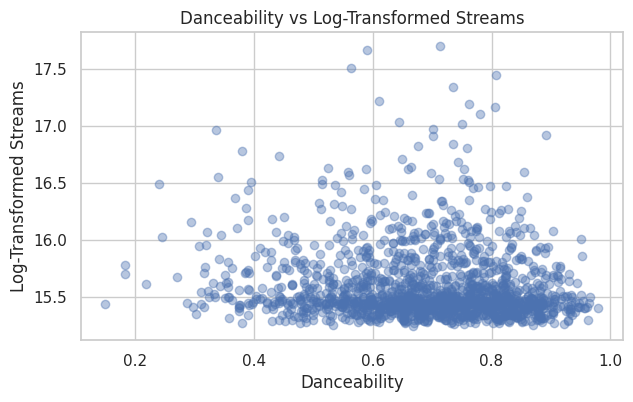

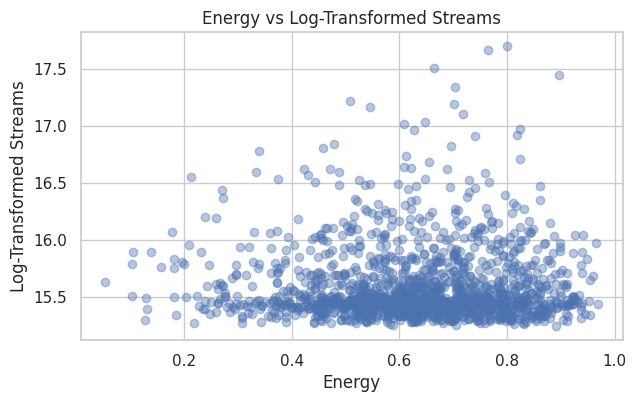

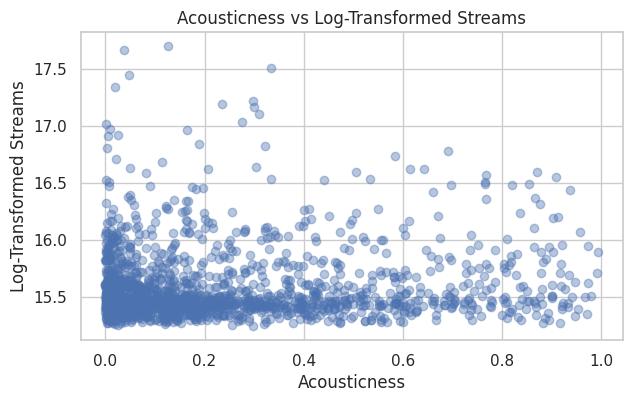

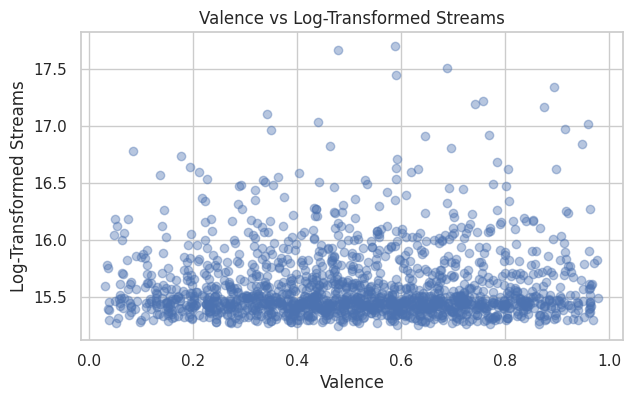

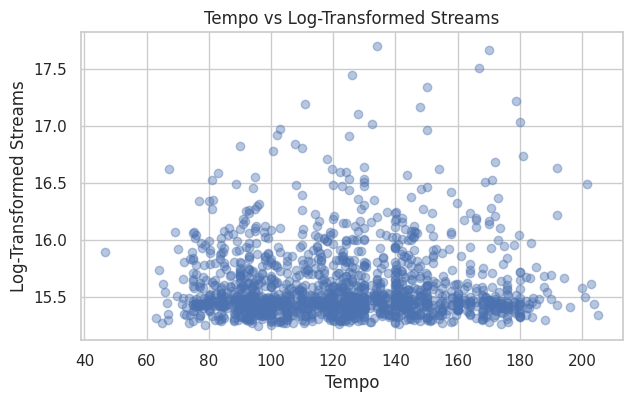

In [20]:
# ============================================================
# Scatterplots of Selected Features vs Log-Transformed Streams
# ============================================================

# Select Features for scatterplots
scatter_features = ["Danceability", "Energy", "Acousticness", "Valence", "Tempo"]

for feature in scatter_features:
    plt.figure(figsize=(7, 4))
    plt.scatter(model_data_clean[feature], model_data_clean["Log_Streams"], alpha=0.4)
    plt.title(feature + " vs Log-Transformed Streams")
    plt.xlabel(feature)
    plt.ylabel("Log-Transformed Streams")
    plt.show()

Interpretation:

The scatterplots do not show a strong simple relationship between individual audio features and streams.

This does not mean the features are useless.

It means the signal may be weak, nonlinear, or dependent on combinations of features.

That is why tree-based models are a reasonable next step.

---

## Why Tree-Based Models?

The scatterplots do not show one simple straight-line relationship between audio features and streams.

That supports using tree-based regression models.

Tree-based models can capture nonlinear patterns, feature interactions, and threshold effects.

In plain language: the model can ask branching questions instead of assuming one straight-line relationship.

---

## Train/Test Split

Next, I split the dataset into training data and testing data.

This helps me check how well the model performs on songs it has never seen before.

- The training data teaches the model patterns in the audio features.
- The testing data is used later to evaluate performance.

This step is important because a model may look accurate if it only memorizes the training data instead of learning useful patterns.

In this project:

- The model learns from one group of songs.
- Then it predicts stream counts for different songs.

Using a train/test split helps give a more realistic measure of model performance.

---



### Prepare Inputs and Two Target Versions

At this stage, I keep the same input features but create two versions of the target.

The question stays the same:

Can audio characteristics help predict Spotify stream counts?

The difference is how the target is represented:

- `Streams` uses the original stream counts.
- `Log_Streams` reduces the effect of extremely large values.

I create:

- one feature matrix: `X`
- two target variables:
  - `y_original`
  - `y_log`

This lets me compare how the models behave with the original target versus the log-transformed target.


In [21]:
# ============================================================
# Prepare Inputs and Two Target Versions
# ============================================================

# Input features
X = model_data_clean[features]

# Original target
y_original = model_data_clean["Streams"]

# Log-transformed target
y_log = model_data_clean["Log_Streams"]


# ============================================================
# Confirm Final Modeling Shape
# ============================================================

print("X shape:", X.shape)
print("y_original shape:", y_original.shape)
print("y_log shape:", y_log.shape)

X shape: (1545, 8)
y_original shape: (1545,)
y_log shape: (1545,)


In [22]:
# ============================================================
# Train/Test Split
# ============================================================

# The model learns from the training data.
# The model is evaluated on testing data it has not already seen.

# Split for original Streams target
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X,
    y_original,
    test_size=0.2,
    random_state=42
)

# Split for log-transformed target
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)


In [23]:
# ============================================================
# Confirm Final Modeling Shapes
# ============================================================

print("Original Target Shapes")
print("X_train:", X_train_original.shape)
print("X_test:", X_test_original.shape)
print("y_train:", y_train_original.shape)
print("y_test:", y_test_original.shape)

print("\nLog Target Shapes")

print("X_train:", X_train_log.shape)
print("X_test:", X_test_log.shape)
print("y_train:", y_train_log.shape)
print("y_test:", y_test_log.shape)

Original Target Shapes
X_train: (1236, 8)
X_test: (309, 8)
y_train: (1236,)
y_test: (309,)

Log Target Shapes
X_train: (1236, 8)
X_test: (309, 8)
y_train: (1236,)
y_test: (309,)


In [24]:
X_train_log.dtypes

,0
Danceability,float64
Energy,float64
Loudness,float64
Speechiness,float64
Acousticness,float64
Liveness,float64
Valence,float64
Tempo,float64


In [25]:
y_train_original.dtypes

dtype('int64')

In [26]:
y_train_log.dtypes

dtype('float64')

### **Evaluation Metrics**

Now that the data is split into training and testing sets, I need a way to measure how well each model performs.

Because this is a regression problem, the model is trying to predict a number: Spotify stream counts.

I use two evaluation metrics:


#### **RMSE**

The main metric is RMSE.

RMSE shows the typical size of the model's prediction error.

In plain language, it tells me how far off the model’s predictions usually are.

Lower RMSE is better.



#### **R² Score**

R² shows how much of the variation in the target the model can explain.

Higher R² is better.

A low R² means the model is not explaining much of the difference in stream counts.

**Why I Use Both?**

RMSE tells me the size of the error.

R² tells me how much overall variation the model explains.

Together, these metrics help me compare:

- models trained on original `Streams`
- models trained on `Log_Streams`

This helps me decide whether the original target or the log-transformed target gives more useful predictions.

In [27]:
# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(model_name, y_test, y_pred):

    # Calculate RMSE
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Calculate R²
    r2 = r2_score(y_test, y_pred)

    # Print results
    print(model_name)
    print("RMSE:", rmse)
    print("R² Score:", r2)

    return rmse, r2

After defining the evaluation metrics, I can now begin training and testing multiple regression models.

Each model will be evaluated using the same metrics so I can compare performance consistently across both target versions.

---

## **Model 1: Decision Tree Regressor**

The first model is a Decision Tree Regressor.

A decision tree makes predictions by splitting the data into smaller groups based on feature values.

For this project, I train the same type of model twice:

- once using the original `Streams` target
- once using the log-transformed `Log_Streams` target

This allows me to compare whether the model performs better when predicting raw stream counts or when predicting a compressed version of stream counts.

In [28]:
# ============================================================
# Model 1: Decision Tree Regressor
# ============================================================

# Decision Tree for original Streams target
tree_original = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_original.fit(X_train_original, y_train_original)


# Decision Tree for log-transformed Streams target
tree_log = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_log.fit(X_train_log, y_train_log)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [29]:
# ============================================================
# Make Predictions
# ============================================================

# Predictions for original Streams target
tree_preds_original = tree_original.predict(X_test_original)

# Predictions for log-transformed target
tree_preds_log = tree_log.predict(X_test_log)

### Evaluate

In [30]:
# ============================================================
# Evaluate Decision Tree Models
# ============================================================

tree_original_rmse, tree_original_r2 = evaluate_model(
    "Decision Tree - Original Streams",
    y_test_original,
    tree_preds_original
)

print()

tree_log_rmse, tree_log_r2 = evaluate_model(
    "Decision Tree - Log Streams",
    y_test_log,
    tree_preds_log
)

Decision Tree - Original Streams
RMSE: 2653627.8922164277
R² Score: -0.03513074232102942

Decision Tree - Log Streams
RMSE: 0.2915613344480797
R² Score: -0.001321052770090425


### **Interpretation**

The **Decision Tree** did not perform very well with either target version.

For the original `Streams` target, the RMSE is extremely large. This means the model’s predictions are often far away from the real stream counts. The R² score is also slightly negative, which means the model is performing worse than simply predicting the average stream count.

For the `Log_Streams` target, the RMSE is much smaller because the target has been compressed onto a log scale. However, the R² score is still slightly negative, so the model is still not explaining the variation in streams well.

This tells me that a single Decision Tree is probably too simple and unstable for this dataset. It can show a few useful signal splits, but it does not generalize well enough on its own.

Because of this, the Decision Tree works best here as a beginner-friendly baseline model rather than the final model.

---


### **Visualization**

This **Decision Tree** visual shows the first few splits of the decision tree.

I limit the depth so the tree is easier to read.

This helps show how the model makes decisions, but it is not meant to explain every prediction perfectly.

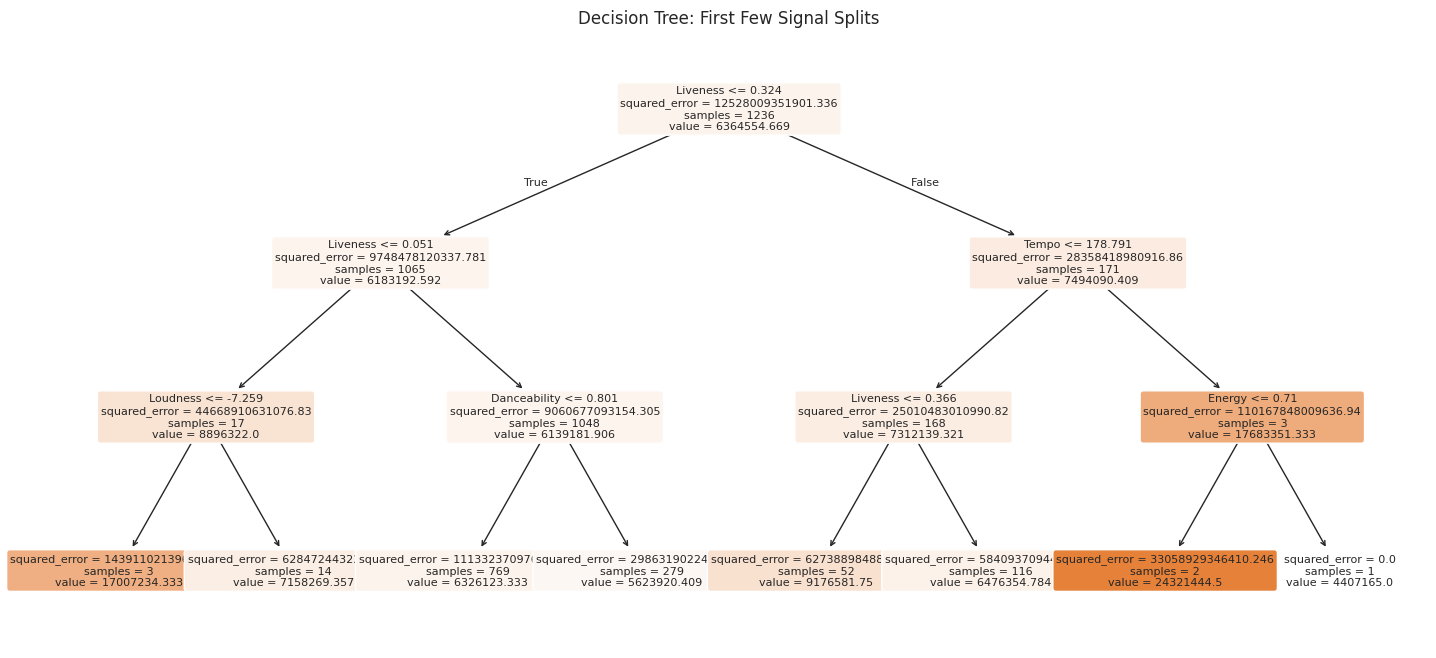

In [31]:
# ============================================================
# Visualize Decision Tree - Original Streams
# ============================================================

# The full tree can become unreadable.
# max_depth=3 shows only the first few levels.

plt.figure(figsize=(18, 8))

plot_tree(
    tree_original,
    feature_names=features,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree: First Few Signal Splits")
plt.show()

**Decision Tree Visualization Interpretation:**

This visualization shows the first few splits made by the Decision Tree model.

The tree separates songs into smaller groups based on audio feature values such as:

- liveness
- tempo
- energy
- loudness
- danceability

Each split represents a decision the model believes helps separate songs with different stream count patterns.

For example, the model may ask questions like:

- Is the song highly energetic?
- Is the tempo fast or slow?
- Does the song have stronger live-performance characteristics?

This helps reveal which audio features the model considers most important early in the prediction process.

However, a single Decision Tree can become unstable because each split depends heavily on the earlier splits before it. Small changes in the data can sometimes produce very different trees.

This is one reason why Decision Trees are often better for understanding model logic than for achieving the strongest predictive performance on their own.

Because of this limitation, the next step is to test a Random Forest model, which combines many decision trees together to create more stable predictions.

---

## **Model 2: Random Forest Regressor**

The second model is a Random Forest Regressor.

A Random Forest improves on a single Decision Tree by building many trees and combining their predictions.

This usually makes the model more stable because it does not depend on one single set of splits.

For this project, I train two Random Forest models:

- one using the original `Streams` target
- one using the log-transformed `Log_Streams` target

This lets me compare whether Random Forest performs better with the raw stream counts or with the compressed log version.

In [32]:
# ============================================================
# Model 2: Random Forest Regressor
# ============================================================

# Random Forest for original Streams target
forest_original = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

forest_original.fit(X_train_original, y_train_original)


# Random Forest for log-transformed Streams target
forest_log = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

forest_log.fit(X_train_log, y_train_log)

RandomForestRegressor(max_depth=8, random_state=42)

In [33]:
# ============================================================
# Make Predictions
# ============================================================

# Predictions for original Streams target
forest_preds_original = forest_original.predict(X_test_original)

# Predictions for log-transformed target
forest_preds_log = forest_log.predict(X_test_log)

### Evaluate

In [34]:
# ============================================================
# Evaluate Random Forest Models
# ============================================================

forest_original_rmse, forest_original_r2 = evaluate_model(
    "Random Forest - Original Streams",
    y_test_original,
    forest_preds_original
)

print()

forest_log_rmse, forest_log_r2 = evaluate_model(
    "Random Forest - Log Streams",
    y_test_log,
    forest_preds_log
)

Random Forest - Original Streams
RMSE: 2773306.9036094933
R² Score: -0.13060532236162725

Random Forest - Log Streams
RMSE: 0.29463040567363924
R² Score: -0.022512477249197138


### Interpretation

The **Random Forest** model performed slightly better than the single Decision Tree model.

For the original `Streams` target, the RMSE remains extremely large because the model is still trying to predict highly skewed stream counts with extreme outliers.

The R² score is still negative, which means the model is not yet explaining the variation in stream counts well enough to outperform a simple average-based prediction.

However, the log-transformed version performed better.

The `Log_Streams` target reduced the influence of extremely large stream counts, which helped the Random Forest model create more stable predictions.

The log-transformed Random Forest produced:

- a smaller RMSE
- an R² score closer to zero

This suggests that the log transformation helped reduce some of the instability caused by the highly skewed distribution.

*Although the model is still weak overall, the improvement between the Decision Tree and Random Forest suggests that combining many trees together helps the model capture more useful signal from the audio features.*

***This also suggests that audio characteristics alone may not fully explain streaming success.***

External factors such as marketing, artist popularity, playlist placement, social media exposure, and release timing likely influence stream counts as well.

---

### **Feature Importance**

Even though the **Random Forest** model is still limited, feature importance can show which audio features the model relied on most.

Because I trained two Random Forest models, I check feature importance for both:

- Random Forest with original `Streams`
- Random Forest with `Log_Streams`

This helps me see whether the same audio features matter across both target versions.

***Important warning:***

Feature importance does **not** prove that a feature causes more streams.

It only shows which features were most useful to the model while making predictions.

In [35]:
# ============================================================
# Random Forest Feature Importance - Original Streams
# ============================================================

forest_original_importance = pd.DataFrame({
    "Feature": features,
    "Importance": forest_original.feature_importances_
})

forest_original_importance = forest_original_importance.sort_values(
    by="Importance",
    ascending=False
)

forest_original_importance

,Feature,Importance
7,Tempo,0.181
5,Liveness,0.151
3,Speechiness,0.134
2,Loudness,0.128
4,Acousticness,0.121
1,Energy,0.101
0,Danceability,0.096
6,Valence,0.087


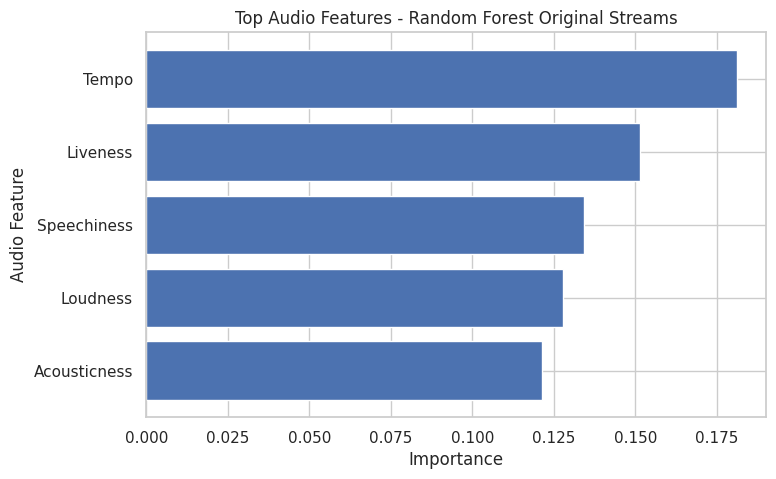

In [36]:
# ============================================================
# Plot Top Features - Original Streams
# ============================================================

top_original_importance = forest_original_importance.head(5)

plt.figure(figsize=(8, 5))

plt.barh(
    top_original_importance["Feature"],
    top_original_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Top Audio Features - Random Forest Original Streams")
plt.xlabel("Importance")
plt.ylabel("Audio Feature")
plt.show()

In [37]:
# ============================================================
# Random Forest Feature Importance - Log Streams
# ============================================================

forest_log_importance = pd.DataFrame({
    "Feature": features,
    "Importance": forest_log.feature_importances_
})

forest_log_importance = forest_log_importance.sort_values(
    by="Importance",
    ascending=False
)

forest_log_importance

,Feature,Importance
5,Liveness,0.173
7,Tempo,0.147
3,Speechiness,0.126
2,Loudness,0.124
6,Valence,0.117
4,Acousticness,0.111
0,Danceability,0.109
1,Energy,0.094


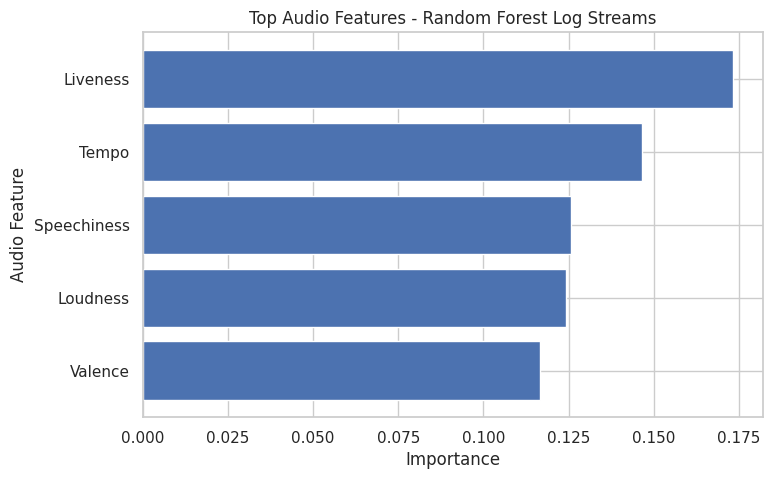

In [38]:
# ============================================================
# Plot Top Features - Log Streams
# ============================================================

top_log_importance = forest_log_importance.head(5)

plt.figure(figsize=(8, 5))

plt.barh(
    top_log_importance["Feature"],
    top_log_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Top Audio Features - Random Forest Log Streams")
plt.xlabel("Importance")
plt.ylabel("Audio Feature")
plt.show()

**Feature Importance Interpretation:**

The **Random Forest** models relied more heavily on some audio features than others.

For both target versions, features such as `Liveness`, `Tempo`, `Speechiness`, `Loudness`, and `Valence` appeared among the strongest signals.

This suggests the model found some consistent patterns within the sound profiles of the songs.

The log-transformed model produced many of the same top features, which suggests that some parts of the audio signal remained important even after reducing the influence of extreme stream counts.

However, the overall model performance was still weak, which means these audio features alone are not enough to strongly predict Spotify streaming success.

This suggests that streaming outcomes are likely influenced by many additional factors outside the audio profile itself, such as artist popularity, marketing, playlist placement, release timing, and social media exposure.

Even so, the feature importance results still help reveal how the model attempted to separate stronger and weaker streaming patterns.

---

## Model 3: XGBoost Regressor

The Random Forest model improved on the single Decision Tree, but the overall predictive performance remained limited.

This suggests that the prediction problem may require a more advanced model capable of learning more complex relationships within the data.

The final model is XGBoost.

Like Random Forest, XGBoost is a tree-based model.

However, instead of building many independent trees, XGBoost builds trees in sequence.

Each new tree attempts to correct the errors made by the previous trees.

Because of this step-by-step learning process, XGBoost is often one of the strongest models for structured data problems.

For this project, I train two XGBoost models:

- one using the original `Streams` target
- one using the log-transformed `Log_Streams` target

Using both target versions helps show whether XGBoost handles the skewed stream distribution more effectively after extreme counts are compressed through log transformation.



In [39]:
# ============================================================
# Model 3: XGBoost Regressor
# ============================================================

# XGBoost for original Streams target
xgb_original = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb_original.fit(X_train_original, y_train_original);


# XGBoost for log-transformed target
xgb_log = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb_log.fit(X_train_log, y_train_log);

**Generate Predictions:**

After training the XGBoost models, I generate predictions on the testing data.

This allows me to compare the predicted stream counts against the real stream counts and evaluate model performance.

In [40]:
# ============================================================
# Make Predictions
# ============================================================

# Predictions for original Streams
xgb_preds_original = xgb_original.predict(X_test_original)

# Predictions for Log Streams
xgb_preds_log = xgb_log.predict(X_test_log)

### Evaluate

In [41]:
# ============================================================
# Evaluate XGBoost Models
# ============================================================

xgb_original_rmse, xgb_original_r2 = evaluate_model(
    "XGBoost - Original Streams",
    y_test_original,
    xgb_preds_original
)

print()

xgb_log_rmse, xgb_log_r2 = evaluate_model(
    "XGBoost - Log Streams",
    y_test_log,
    xgb_preds_log
)

XGBoost - Original Streams
RMSE: 2902525.2453682465
R² Score: -0.2384178638458252

XGBoost - Log Streams
RMSE: 0.3085483380098078
R² Score: -0.12139834703816721


### Interpretation

XGBoost Evaluation Interpretation

XGBoost was tested with both target versions.

For the original `Streams` target, the RMSE is very large and the R² score is negative. This means the model still struggled to predict raw stream counts accurately.

For the `Log_Streams` target, the RMSE is much smaller because the target is compressed onto a log scale. However, the R² score is still negative, so the model is still not explaining stream variation well.

This is important because XGBoost is the most advanced model tested so far.

If even XGBoost struggles, that suggests the issue is not just model choice.

***The bigger finding is that audio features alone may not contain enough information to reliably predict Spotify streaming success.***

Still, XGBoost can help show which audio features it relied on most while trying to make predictions.

That is why the next step is feature importance.

---


### **Feature Importance**

XGBoost Feature Importance:

Next, I examine which audio features the XGBoost models relied on most.

Because XGBoost learns sequentially, its feature importance rankings may differ from the Random Forest results.

Comparing feature importance across models helps show whether certain audio characteristics consistently appear as important predictive signals.

In [42]:
# ============================================================
# XGBoost Feature Importance - Original Streams
# ============================================================

xgb_original_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_original.feature_importances_
})

xgb_original_importance = xgb_original_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_original_importance

,Feature,Importance
3,Speechiness,0.177
7,Tempo,0.159
5,Liveness,0.130
2,Loudness,0.125
1,Energy,0.113
4,Acousticness,0.111
0,Danceability,0.106
6,Valence,0.079


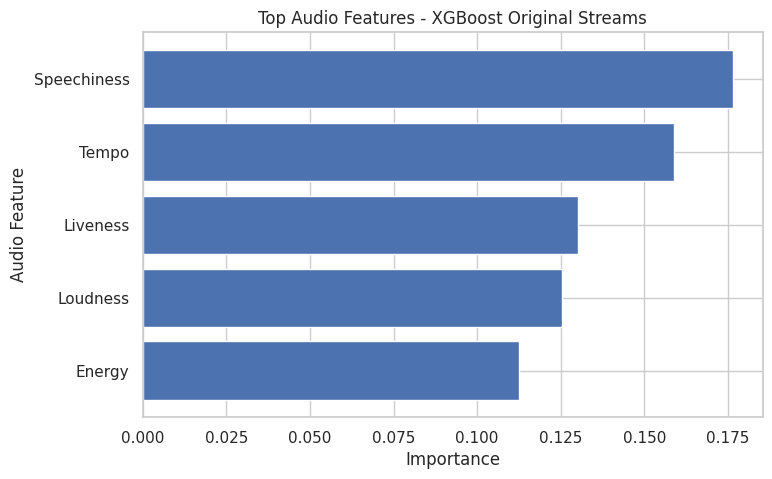

In [43]:
# ============================================================
# Plot XGBoost Feature Importance - Original Streams
# ============================================================

top_xgb_original = xgb_original_importance.head(5)

plt.figure(figsize=(8, 5))

plt.barh(
    top_xgb_original["Feature"],
    top_xgb_original["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Audio Features - XGBoost Original Streams")
plt.xlabel("Importance")
plt.ylabel("Audio Feature")

plt.show()

In [44]:
# ============================================================
# XGBoost Feature Importance - Log Streams
# ============================================================

xgb_log_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_log.feature_importances_
})

xgb_log_importance = xgb_log_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_log_importance

,Feature,Importance
2,Loudness,0.161
3,Speechiness,0.148
5,Liveness,0.132
4,Acousticness,0.129
7,Tempo,0.125
6,Valence,0.107
0,Danceability,0.103
1,Energy,0.096


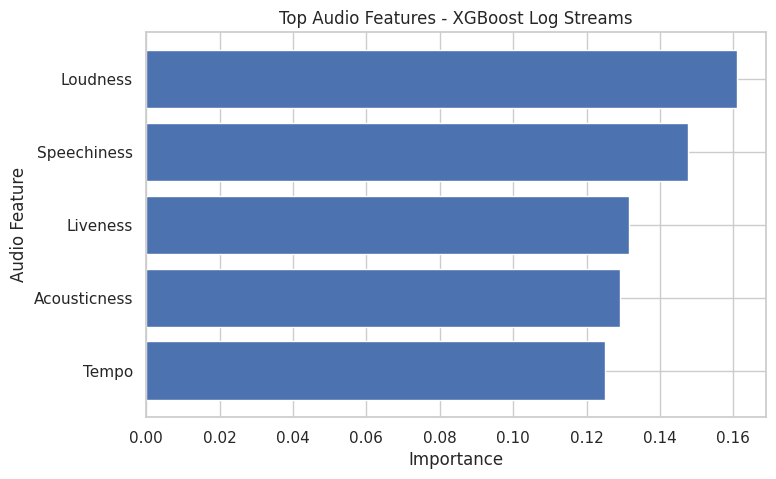

In [45]:
# ============================================================
# Plot XGBoost Feature Importance - Log Streams
# ============================================================

top_xgb_log = xgb_log_importance.head(5)

plt.figure(figsize=(8, 5))

plt.barh(
    top_xgb_log["Feature"],
    top_xgb_log["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Audio Features - XGBoost Log Streams")
plt.xlabel("Importance")
plt.ylabel("Audio Feature")

plt.show()

XGBoost Feature Importance Interpretation:

The XGBoost feature importance results show which audio features the model relied on most while making predictions.

For the original `Streams` target, the strongest features included `Speechiness`, `Tempo`, `Liveness`, `Loudness`, and `Energy`.

For the `Log_Streams` target, the strongest features shifted slightly and included `Loudness`, `Speechiness`, `Liveness`, `Acousticness`, and `Tempo`.

This is useful because several features appear near the top in both versions, especially `Speechiness`, `Tempo`, `Liveness`, and `Loudness`.

That suggests XGBoost found some consistent signal in the sound profile of the songs.

However, the model’s overall performance was still weak, so these features should not be interpreted as strong predictors by themselves.

***The main takeaway is that XGBoost found some repeated audio patterns, but those patterns were not strong enough to reliably predict streaming success.***

## Model Comparison

Now that all three models have been trained and evaluated, I compare their performance side by side.

For each target, I compare:

- Decision Tree
- Random Forest
- XGBoost

The main metrics are:

- RMSE
- R² Score

The best model should have:

- lower RMSE
- higher R²

This comparison helps answer two main questions:

- Which model performed best?
- Did the log-transformed target improve performance?


However, if all models have weak scores, that is still an important finding.

It may mean that audio features alone are not enough to predict streams well.

In [46]:
# ============================================================
# Compare Models - Original Streams
# ============================================================

results_original = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "RMSE": [
        tree_original_rmse,
        forest_original_rmse,
        xgb_original_rmse
    ],
    "R2 Score": [
        tree_original_r2,
        forest_original_r2,
        xgb_original_r2
    ]
})

results_original

,Model,RMSE,R2 Score
0,Decision Tree,"2,653,627.892",-0.035
1,Random Forest,"2,773,306.904",-0.131
2,XGBoost,"2,902,525.245",-0.238


In [47]:
# ============================================================
# Compare Models - Log Streams
# ============================================================

results_log = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "RMSE": [
        tree_log_rmse,
        forest_log_rmse,
        xgb_log_rmse
    ],
    "R2 Score": [
        tree_log_r2,
        forest_log_r2,
        xgb_log_r2
    ]
})

results_log

,Model,RMSE,R2 Score
0,Decision Tree,0.292,-0.001
1,Random Forest,0.295,-0.023
2,XGBoost,0.309,-0.121


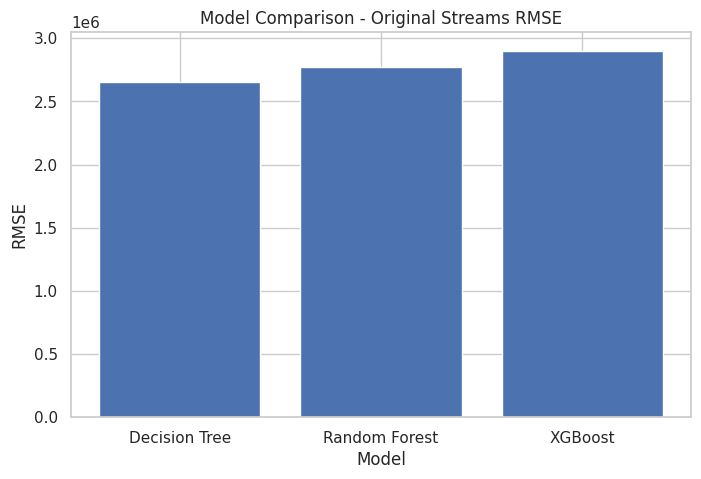

In [48]:
# ============================================================
# RMSE Comparison - Original Streams
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_original["Model"],
    results_original["RMSE"]
)

plt.title("Model Comparison - Original Streams RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks()

plt.show()

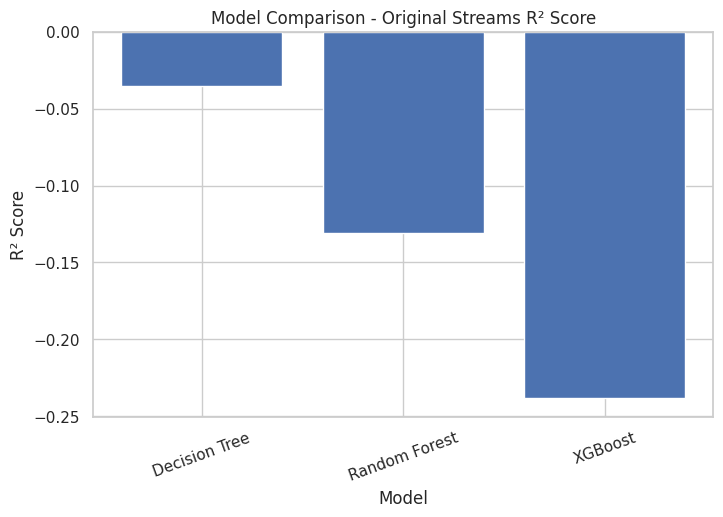

In [49]:
# ============================================================
# R² Comparison - Original Streams
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_original["Model"],
    results_original["R2 Score"]
)

plt.title("Model Comparison - Original Streams R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

**Model Comparison - Log Streams**

Next, I compare the same models using the log-transformed target.

The log transformation compresses the extreme stream counts and reduces the influence of major outliers.

This helps test whether the models perform more consistently after reducing skew in the target distribution.

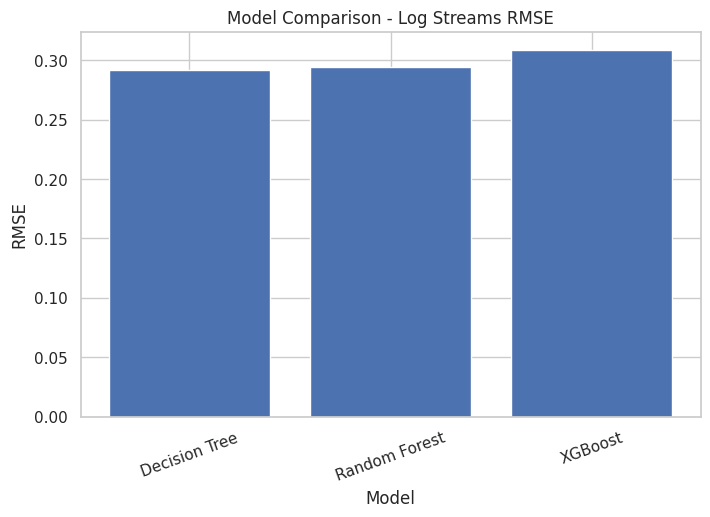

In [50]:
# ============================================================
# RMSE Comparison - Log Streams
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_log["Model"],
    results_log["RMSE"]
)

plt.title("Model Comparison - Log Streams RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

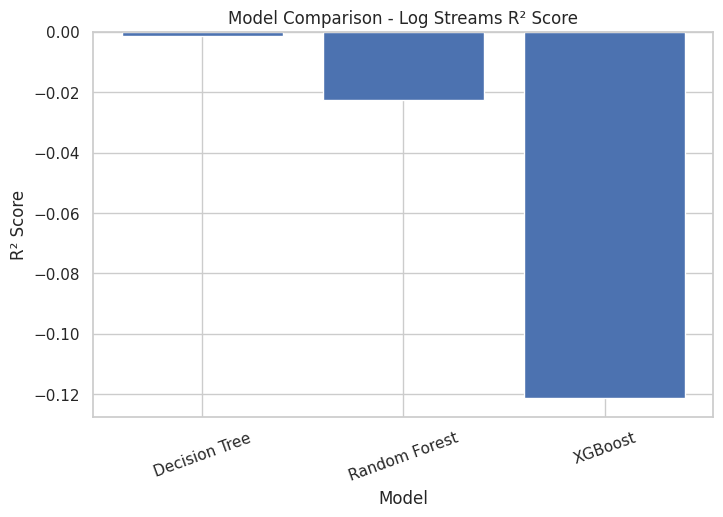

In [51]:
# ============================================================
# R² Comparison - Log Streams
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_log["Model"],
    results_log["R2 Score"]
)

plt.title("Model Comparison - Log Streams R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

### **Model Performance**

Across both target versions, all three models struggled to accurately predict Spotify stream counts using audio features alone.

The log-transformed target generally performed slightly better because compressing the extreme stream counts reduced some of the instability caused by outliers.

However, even the strongest models still produced weak R² scores.

This suggests that while audio characteristics contain some predictive signal, they are not enough by themselves to fully explain streaming success.


### **Actual vs Predicted Streams**

Finally, I visualize how closely the predictions matched the real stream counts.

If the model performed very well, the points would form a clear diagonal pattern.

If the points appear widely scattered, that suggests the model struggled to make accurate predictions.

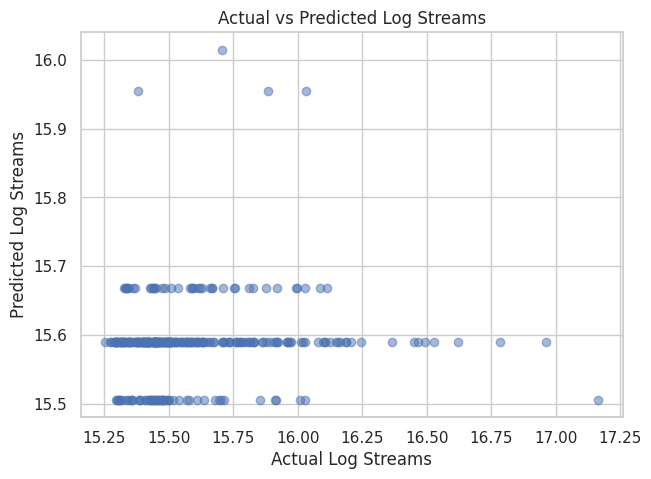

Best Log Model: Decision Tree


In [52]:
# ============================================================
# Actual vs Predicted - Best Log Model
# ============================================================

best_log_model = results_log.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]

if best_log_model == "Decision Tree":
    best_preds = tree_preds_log

elif best_log_model == "Random Forest":
    best_preds = forest_preds_log

else:
    best_preds = xgb_preds_log

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_log,
    best_preds,
    alpha=0.5
)

plt.title("Actual vs Predicted Log Streams")
plt.xlabel("Actual Log Streams")
plt.ylabel("Predicted Log Streams")

plt.show()

print("Best Log Model:", best_log_model)

## Conclusion

After training all three models with both target versions, I compare their performance side by side.

I look at two questions:

- Which model performed best?
- Did the log-transformed target improve prediction?

Overall, all three models struggled to predict Spotify stream counts using audio features alone.

The original `Streams` models had very large RMSE values because the target contains extreme high-streaming songs.

The `Log_Streams` models were more stable because the log transformation reduced the impact of those extreme values.

However, the R² scores were still weak or negative.

This means the models did not explain much of the variation in Spotify stream counts.

The actual vs predicted plot supports this conclusion.

If the model were performing well, the points would form a clear diagonal pattern.

Instead, the points are scattered and clustered, which shows that the model’s predictions were not closely aligned with the real values.

***This does not mean the project failed.***

It means the modeling results revealed an important finding:

Audio characteristics alone are not enough to reliably predict Spotify streaming success.

The audio features describe the sound of a song, but streaming success is also shaped by outside factors such as:

- artist popularity
- playlist placement
- marketing exposure
- social media activity
- release timing
- cultural momentum


***Rather than representing project failure, these results became an important analytical finding:***

**audio characteristics alone are not sufficient to reliably predict Spotify streaming success.**

In sound engineering terms:

the audio features are important channels in the mix, but they are not the whole song.

In other words:

the model was trying to predict resonance using only the frequencies inside the track, while missing the surrounding speakers, audience, environment, and amplification systems that shape real-world popularity.

## What I Would Do Next

For a future version of this project, I would improve the model by:

1. Adding non-audio features, such as artist popularity, genre, playlist placement, or release timing.
2. Comparing audio-only models against models that include popularity and context features.
3. Testing whether the model performs better after grouping songs by genre or popularity level.
4. Using cross-validation for a stronger model evaluation process.

The next version would ask a more advanced question:

Can audio features predict streams better when combined with artist, platform, and marketing context?